
# FarmTech Solutions: Visão Computacional com YOLOv5

 **Projeto da Fase 6.**
 Objetivo: demonstrar a um cliente fictício da FarmTech como funciona um sistema de visão computacional na prática, treinando o YOLOv5 para detectar dois objetos bem diferentes: **vaca** e **bicicleta**.

Autor: Antonio Filipe de Souza Branco (RM 573837)


## Como executar

1. Abra o link da pasta do projeto no Google Drive: **https://drive.google.com/drive/folders/1gz_ejuuDiEIgJNe1DnIa7cBvoya6AeVr?usp=drive_link**
2. No Drive, clique com o botão direito na pasta `FarmTech_Fase6`, escolha **Organizar > Adicionar atalho ao Drive** e selecione "Meu Drive". O caminho esperado pelo notebook é `/content/drive/MyDrive/FarmTech_Fase6/dataset_vaca_bicicleta`.
3. No Colab, ative a GPU em *Ambiente de execução > Alterar tipo de ambiente de execução > T4*.
4. Execute as células em ordem.

**Observações:**
- As saídas dos treinos (30 e 60 épocas) já estão salvas neste notebook. Cada treino leva cerca de 11 e 21 minutos, respectivamente.
- As células de treino, `val.py` e `detect.py` gravam resultados na pasta do Drive, o que exige permissão de edição. Sem ela, é possível apenas conferir as saídas já salvas.

## 1. Dataset

- 40 imagens de vacas e 40 de bicicletas (80 no total), utilizadas exclusivamente para fins acadêmicos. Fontes: magnific.com e pinterest.com
- Divisão por classe: 32 treino, 4 validação e 4 teste.
- Organização no Drive: `images` e `labels`, cada uma com `train`, `val` e `test`.

As células abaixo montam o Drive e conferem se todos os arquivos estão no lugar (esperado: 64, 64, 8, 8, 8, 8).

## 2. Rotulação

As imagens foram rotuladas no site Make Sense, com caixas (bounding boxes) em cada objeto e exportação no formato YOLO. Classes: 0 = vaca, 1 = bicicleta. Cada imagem tem um `.txt` com o mesmo nome, e cada linha traz a classe e a posição da caixa.

In [ ]:
# Importa o módulo que permite conectar o Google Drive ao Colab
from google.colab import drive

# Monta o Drive em /content/drive para o notebook enxergar imagens e rótulos
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# Lista o conteúdo da pasta do dataset (esperado: images e labels)
!ls /content/drive/MyDrive/FarmTech_Fase6/dataset_vaca_bicicleta

images	labels


In [ ]:
# Guarda o endereço do dataset numa variável para não repetir o caminho
base = '/content/drive/MyDrive/FarmTech_Fase6/dataset_vaca_bicicleta'
# Conta as imagens de treino (esperado: 64)
!ls {base}/images/train | wc -l
# Conta os rótulos de treino (esperado: 64)
!ls {base}/labels/train | wc -l
# Conta as imagens de validação (esperado: 8)
!ls {base}/images/val | wc -l
# Conta os rótulos de validação (esperado: 8)
!ls {base}/labels/val | wc -l
# Conta as imagens de teste (esperado: 8)
!ls {base}/images/test | wc -l
# Conta os rótulos de teste (esperado: 8)
!ls {base}/labels/test | wc -l

64
64
8
8
8
8


## 3. Preparação do YOLOv5

Clonamos o repositório oficial do YOLOv5 e instalamos as dependências. Em seguida, criamos o `data.yaml`, que informa ao modelo onde estão as imagens e quais são as classes.

In [ ]:
# Clona o repositório oficial do YOLOv5 (código de treino e detecção)
!git clone https://github.com/ultralytics/yolov5

Cloning into 'yolov5'...
remote: Enumerating objects: 18764, done.
remote: Counting objects: 100% (320/320), done.
remote: Compressing objects: 100% (186/186), done.
remote: Total 18764 (delta 262), reused 134 (delta 134), pack-reused 18444 (from 5)
Receiving objects: 100% (18764/18764), 17.80 MiB | 23.27 MiB/s, done.
Resolving deltas: 100% (12765/12765), done.


In [ ]:
# Entra na pasta do YOLOv5 para executar os scripts a partir dela
%cd yolov5
# Instala as bibliotecas listadas no requirements.txt (PyTorch, OpenCV etc.)
!pip install -r requirements.txt

/content/yolov5
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.7/46.7 kB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 47.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 95.5/95.5 kB 10.5 MB/s eta 0:00:00


In [ ]:
%%writefile data.yaml
# Pasta principal do dataset no Drive
path: /content/drive/MyDrive/FarmTech_Fase6/dataset_vaca_bicicleta
# Subpastas de imagens (os rótulos são buscados em labels/ automaticamente)
train: images/train
val: images/val
test: images/test
# Classes, na mesma ordem usada na rotulação do Make Sense
names:
  0: vaca
  1: bicicleta

Writing data.yaml


## 4. Treinamento

### Simulação 1: 30 épocas
Partimos do modelo pré-treinado `yolov5s` (transfer learning) e o treinamos com nossas imagens por 30 épocas. Os resultados ficam em `runs/train/treino_30ep`.

In [ ]:
# Treina o YOLOv5 pequeno (yolov5s) por 30 épocas, partindo de pesos pré-treinados
# --img: tamanho das imagens | --batch: imagens por lote | --name: pasta dos resultados
!python train.py --img 640 --batch 16 --epochs 30 --data data.yaml --weights yolov5s.pt --name treino_30ep

Creating new Ultralytics Settings v0.0.8 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/usage/settings.
WARNING ⚠️ wandb: wandb is deprecated and will be removed in a future release. See supported integrations at https://github.com/ultralytics/yolov5#integrations.
wandb: (1) Create a W&B account
wandb: (2) Use an existing W&B account
wandb: (3) Don't visualize my results
wandb: Enter your choice: (30 second timeout) 
wandb: WARNING W&B disabled due to login timeout.
wandb: W&B API key is configured. Use `wandb login --relogin` to force relogin
train: weights=yolov5s.pt, cfg=, data=data.yaml, hyp=data/hyps/hyp.scratch-low.yaml, epochs=30, batch_size=16, imgsz=640, rect=False, resume=False, nosave=False, noval=False, noautoanchor=False, noplots=False, evolve=None, evolve_population=data/hyps, resume_ev

In [ ]:
# Copia a pasta runs (resultados do treino) para o Drive, para não perder ao fechar o Colab
!cp -r /content/yolov5/runs /content/drive/MyDrive/FarmTech_Fase6/

In [ ]:
# Simulação 2: 60 épocas, salvando os resultados direto no Drive
!python train.py --img 640 --batch 16 --epochs 60 --data data.yaml --weights yolov5s.pt --project /content/drive/MyDrive/FarmTech_Fase6/runs/train --name treino_60ep

WARNING ⚠️ wandb: wandb is deprecated and will be removed in a future release. See supported integrations at https://github.com/ultralytics/yolov5#integrations.
wandb: (1) Create a W&B account
wandb: (2) Use an existing W&B account
wandb: (3) Don't visualize my results
wandb: Enter your choice: (30 second timeout) 
wandb: WARNING W&B disabled due to login timeout.
wandb: W&B API key is configured. Use `wandb login --relogin` to force relogin
train: weights=yolov5s.pt, cfg=, data=data.yaml, hyp=data/hyps/hyp.scratch-low.yaml, epochs=60, batch_size=16, imgsz=640, rect=False, resume=False, nosave=False, noval=False, noautoanchor=False, noplots=False, evolve=None, evolve_population=data/hyps, resume_evolve=None, bucket=, cache=None, image_weights=False, device=, multi_scale=False, single_cls=False, optimizer=SGD, sync_bn=False, workers=8, project=/content/drive/MyDrive/FarmTech_Fase6/runs/train, name=treino_60ep, exist_ok=False, quad=False, cos_lr=False, label_smoothing=0.0, patience=100, 

## 5. Resultados

### 5.1 Treino e validação (8 imagens)

| Métrica | 30 épocas | 60 épocas |
|---|---|---|
| Precisão | 0,929 | 0,880 |
| Recall | 1,0 | 1,0 |
| mAP50 | 0,995 | 0,995 |
| mAP50-95 | 0,661 | 0,784 |
| Tempo de treino | 0,177 h | 0,348 h |
| Perda final de treino, última época (box / obj / cls) | 0,057 / 0,019 / 0,0059 | 0,038 / 0,015 / 0,0027 |

Na validação, os dois modelos acharam todos os objetos. O modelo de 60 épocas desenhou caixas mais justas (mAP50-95 maior), mas a métrica oscilou ao longo das épocas: o melhor valor apareceu por volta da época 36.

treino_30ep


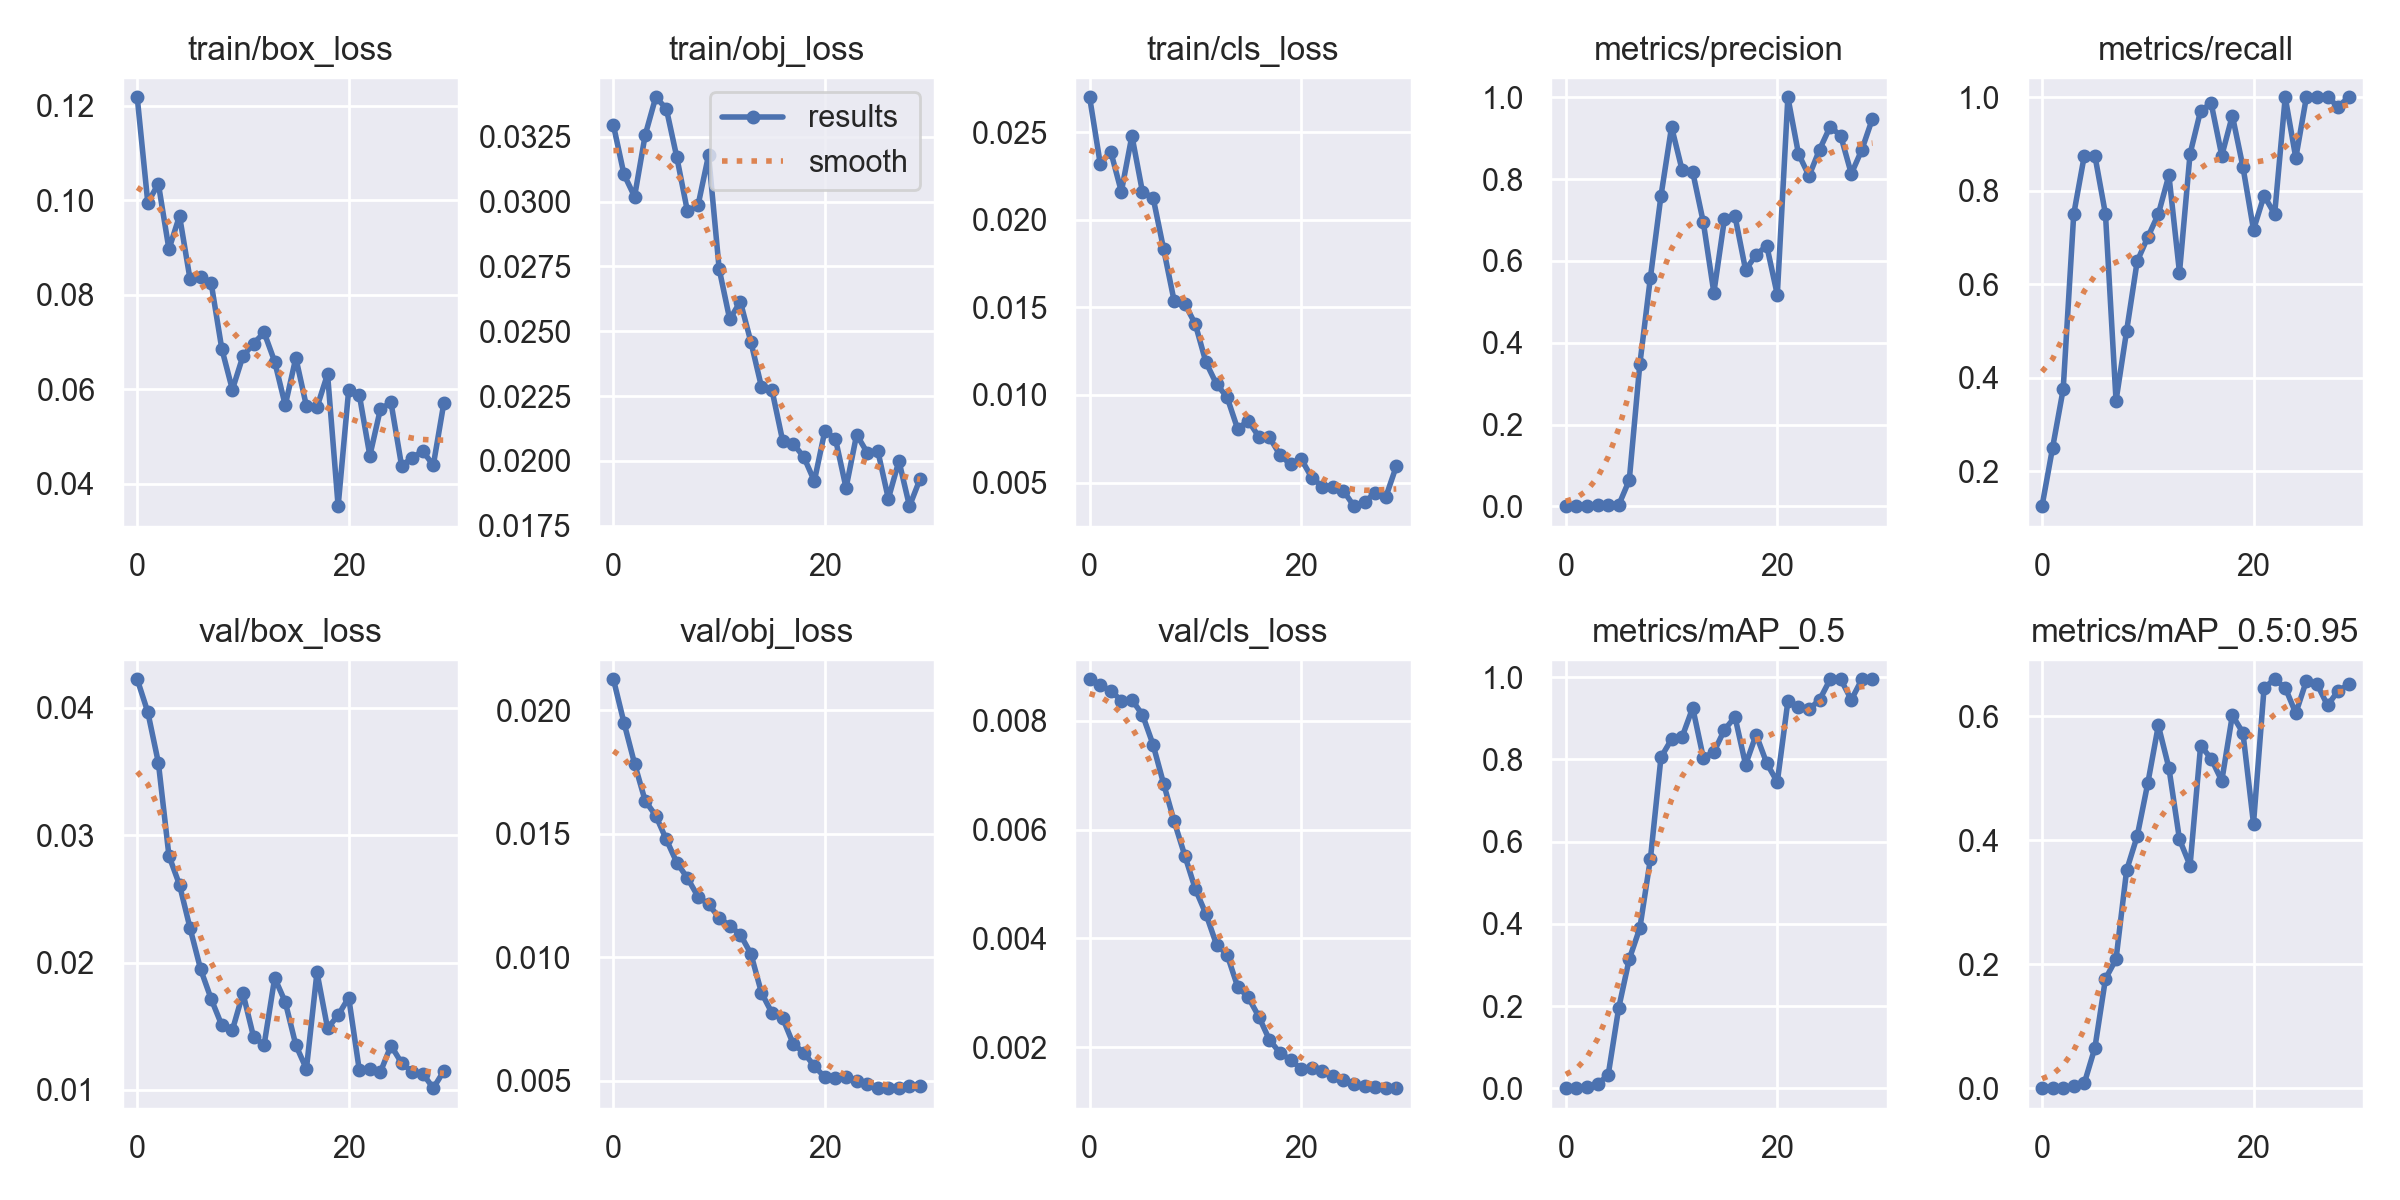

treino_60ep


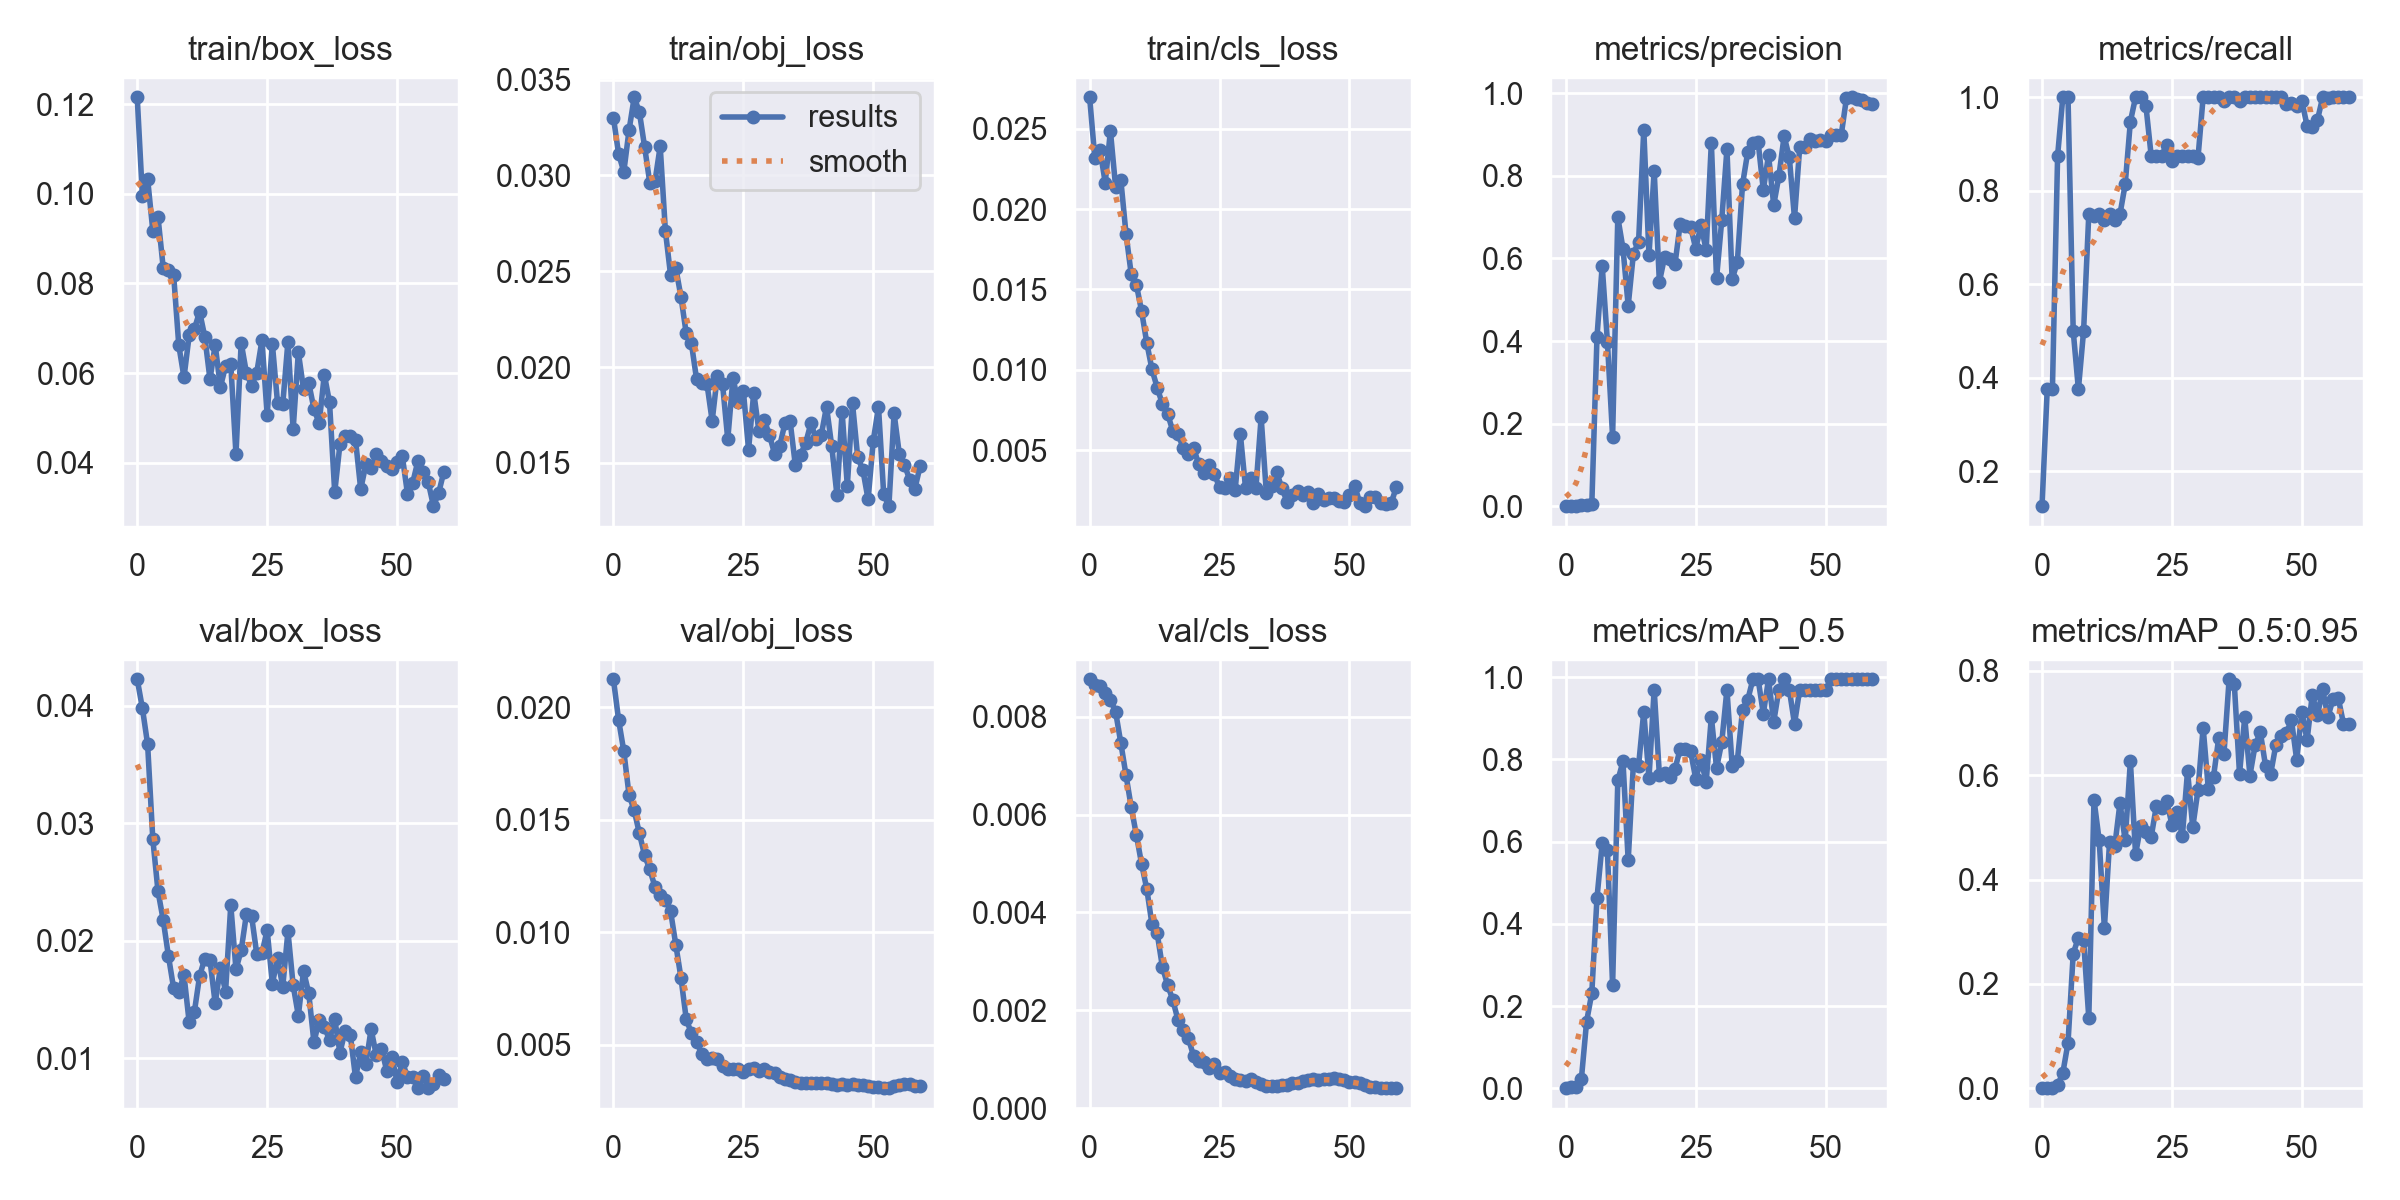

In [ ]:
# Importa as ferramentas para exibir imagens no notebook
from IPython.display import Image, display

# Exibe as curvas de erro (loss) e de métricas do treino de 30 e de 60 épocas
for nome in ['treino_30ep', 'treino_60ep']:
    # Mostra o nome do treino antes do gráfico
    print(nome)
    # Carrega o gráfico results.png salvo pelo YOLOv5 no Drive
    display(Image(filename=f'/content/drive/MyDrive/FarmTech_Fase6/runs/train/{nome}/results.png', width=800))

### Validação e teste (val.py)
Avaliamos o `best.pt` de cada treino no conjunto de teste, formado por imagens que o modelo nunca viu. O `val.py` compara cada caixa prevista com o rótulo real e calcula precisão, recall e mAP.

In [ ]:
# Avalia o modelo de 30 épocas no conjunto de teste (imagens que ele nunca viu)
!python val.py --weights /content/drive/MyDrive/FarmTech_Fase6/runs/train/treino_30ep/weights/best.pt --data data.yaml --task test --img 640 --project /content/drive/MyDrive/FarmTech_Fase6/runs/val --name teste_30ep

val: data=data.yaml, weights=['/content/drive/MyDrive/FarmTech_Fase6/runs/train/treino_30ep/weights/best.pt'], batch_size=32, imgsz=640, conf_thres=0.001, iou_thres=0.6, max_det=300, task=test, device=, workers=8, single_cls=False, augment=False, verbose=False, save_txt=False, save_hybrid=False, save_conf=False, save_json=False, project=/content/drive/MyDrive/FarmTech_Fase6/runs/val, name=teste_30ep, exist_ok=False, half=False, dnn=False
YOLOv5 🚀 v7.0-555-g4add2aff Python-3.13.15 torch-2.11.0+cu130 CUDA:0 (Tesla T4, 14913MiB)

Fusing layers... 
Model summary: 68 layers, 7,015,519 parameters, 0 gradients, 15.8 GFLOPs
test: Scanning /content/drive/MyDrive/FarmTech_Fase6/dataset_vaca_bicicleta/labels/test... 8 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 8/8 2.6s/it 20.4s
test: New cache created: /content/drive/MyDrive/FarmTech_Fase6/dataset_vaca_bicicleta/labels/test.cache
                 Class     Images  Instances          P          R      mAP50   mAP50-95: 100% ━━━━━━━━━━━━ 1

In [ ]:
# Avalia o modelo de 60 épocas no mesmo conjunto de teste
!python val.py --weights /content/drive/MyDrive/FarmTech_Fase6/runs/train/treino_60ep/weights/best.pt --data data.yaml --task test --img 640 --project /content/drive/MyDrive/FarmTech_Fase6/runs/val --name teste_60ep

val: data=data.yaml, weights=['/content/drive/MyDrive/FarmTech_Fase6/runs/train/treino_60ep/weights/best.pt'], batch_size=32, imgsz=640, conf_thres=0.001, iou_thres=0.6, max_det=300, task=test, device=, workers=8, single_cls=False, augment=False, verbose=False, save_txt=False, save_hybrid=False, save_conf=False, save_json=False, project=/content/drive/MyDrive/FarmTech_Fase6/runs/val, name=teste_60ep, exist_ok=False, half=False, dnn=False
YOLOv5 🚀 v7.0-555-g4add2aff Python-3.13.15 torch-2.11.0+cu130 CUDA:0 (Tesla T4, 14913MiB)

Fusing layers... 
Model summary: 68 layers, 7,015,519 parameters, 0 gradients, 15.8 GFLOPs
test: Scanning /content/drive/MyDrive/FarmTech_Fase6/dataset_vaca_bicicleta/labels/test.cache... 8 images, 0 backgrounds, 0 corrupt
                 Class     Images  Instances          P          R      mAP50   mAP50-95: 100% ━━━━━━━━━━━━ 1/1 3.0s/it 3.0s
                   all          8          8      0.899      0.713      0.912      0.736
                  vaca        

### Detecção nas imagens de teste (detect.py)
Aplicamos cada modelo às 8 imagens de teste e salvamos as imagens com as caixas desenhadas, a classe e a confiança. Também salvamos arquivos de texto com as confianças de cada detecção.

In [1]:
# Detecta objetos nas imagens de teste com o modelo de 30 épocas e salva as imagens com as caixas
!python detect.py --weights /content/drive/MyDrive/FarmTech_Fase6/runs/train/treino_30ep/weights/best.pt --source /content/drive/MyDrive/FarmTech_Fase6/dataset_vaca_bicicleta/images/test --img 640 --line-thickness 6 --save-txt --save-conf --project /content/drive/MyDrive/FarmTech_Fase6/runs/detect --name detect_30ep --exist-ok

python3: can't open file '/content/detect.py': [Errno 2] No such file or directory


In [2]:
# Mesma detecção com o modelo de 60 épocas, para comparar visualmente
!python detect.py --weights /content/drive/MyDrive/FarmTech_Fase6/runs/train/treino_60ep/weights/best.pt --source /content/drive/MyDrive/FarmTech_Fase6/dataset_vaca_bicicleta/images/test --img 640 --line-thickness 6 --save-txt --save-conf --project /content/drive/MyDrive/FarmTech_Fase6/runs/detect --name detect_60ep --exist-ok

python3: can't open file '/content/detect.py': [Errno 2] No such file or directory


In [ ]:
# Importa as ferramentas para localizar arquivos, redimensionar e exibir imagens
import glob, io
from PIL import Image as PILImage
from IPython.display import Image, display

# Função que exibe as imagens de uma pasta de resultados, reduzidas para deixar o notebook leve
def mostrar_resultados(pasta):
    # Percorre as imagens .jpg da pasta em ordem alfabética
    for caminho in sorted(glob.glob(pasta + '/*.jpg')):
        # Imprime o nome do arquivo antes da imagem
        print(caminho.split('/')[-1])
        # Abre a imagem e reduz para no máximo 700 pixels
        img = PILImage.open(caminho)
        img.thumbnail((700, 700))
        # Converte para JPEG comprimido em memória
        buf = io.BytesIO()
        img.save(buf, format='JPEG', quality=85)
        # Exibe a imagem reduzida no notebook
        display(Image(data=buf.getvalue(), format='jpeg'))

bicicleta_37.jpg


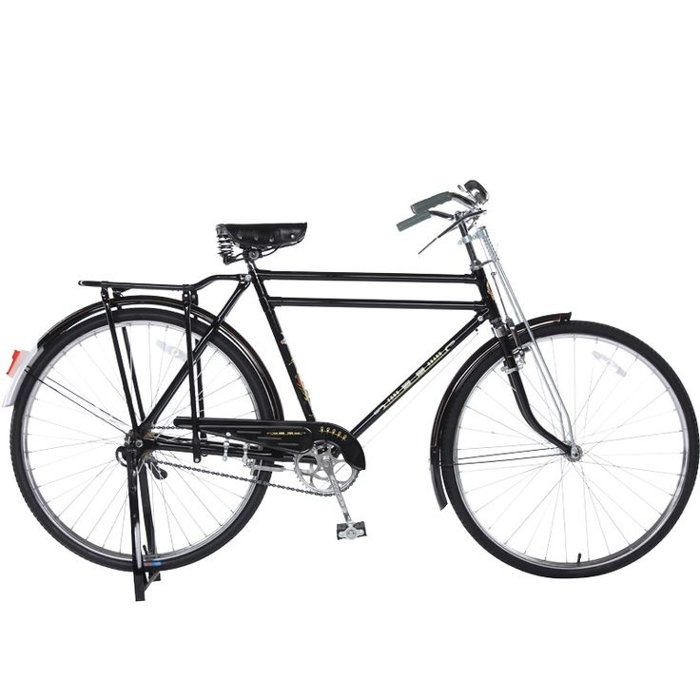

bicicleta_38.jpg


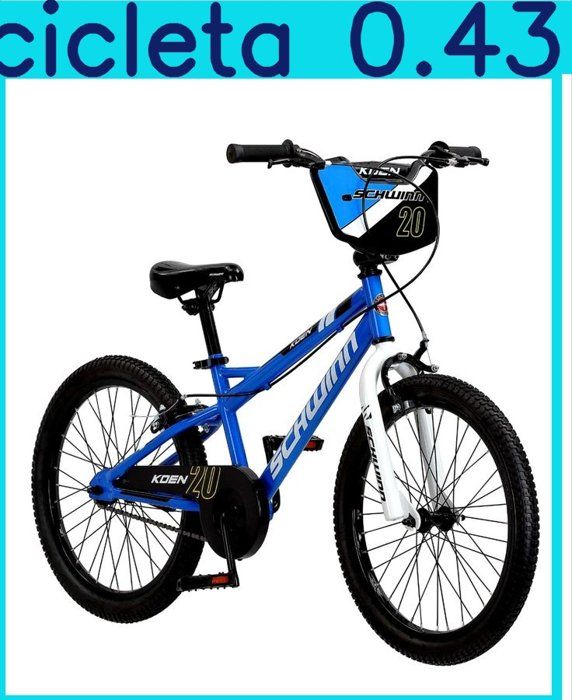

bicicleta_39.jpg


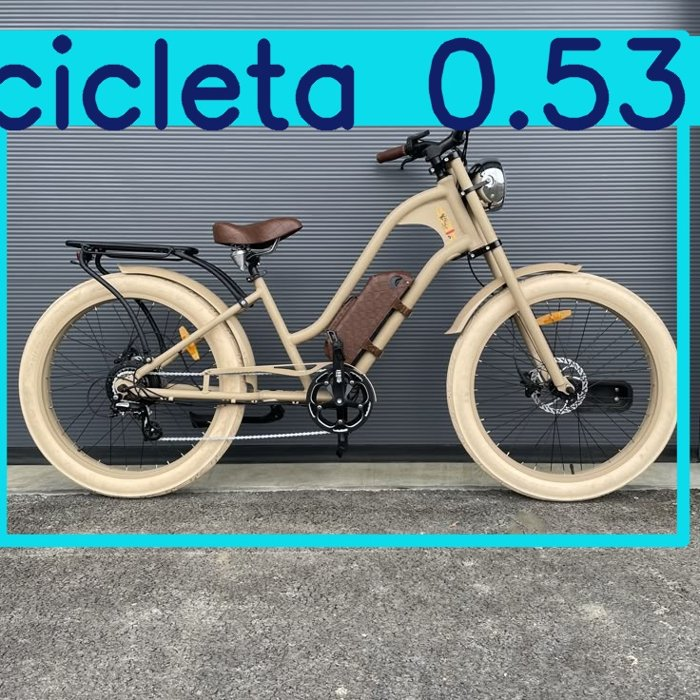

bicicleta_40.jpg


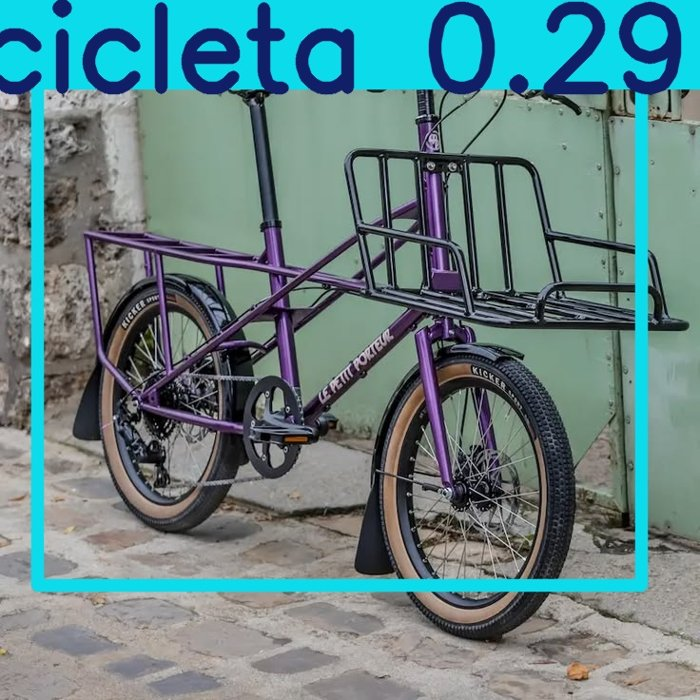

vaca_37.jpg


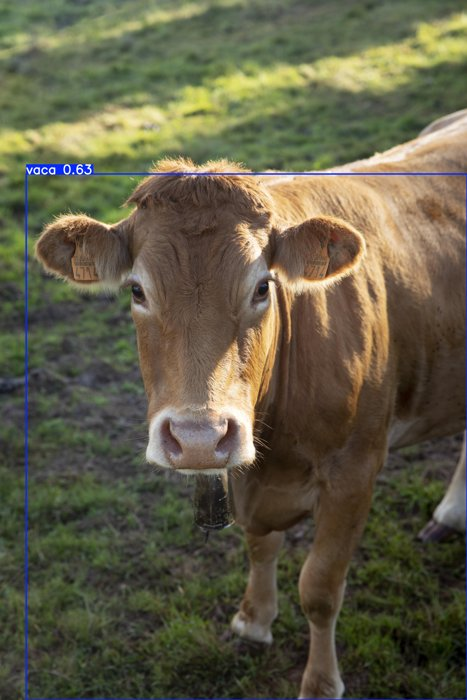

vaca_38.jpg


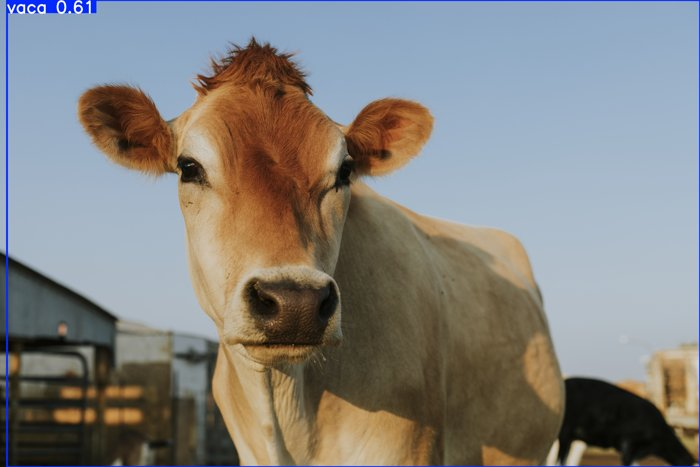

vaca_39.jpg


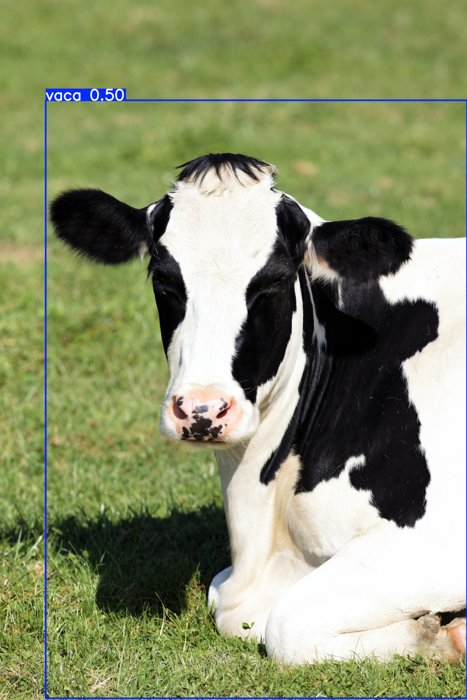

vaca_40.jpg


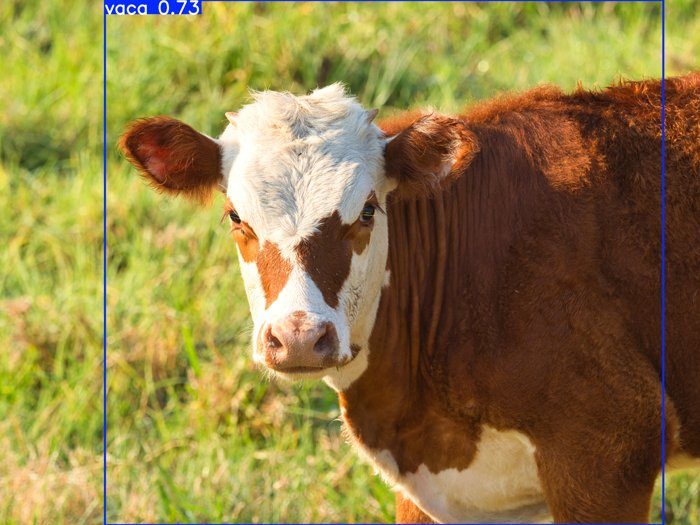

In [ ]:
# Mostra as detecções do modelo de 30 épocas nas imagens de teste
mostrar_resultados('/content/drive/MyDrive/FarmTech_Fase6/runs/detect/detect_30ep')

bicicleta_37.jpg


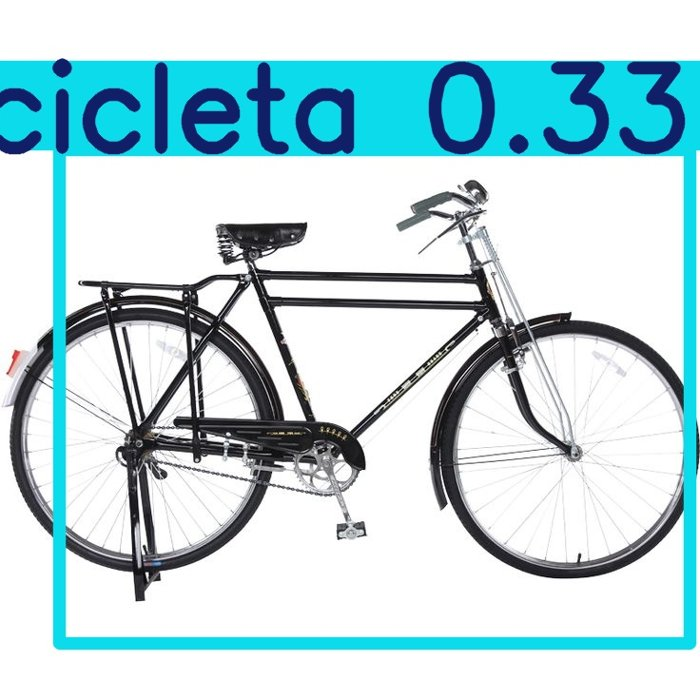

bicicleta_38.jpg


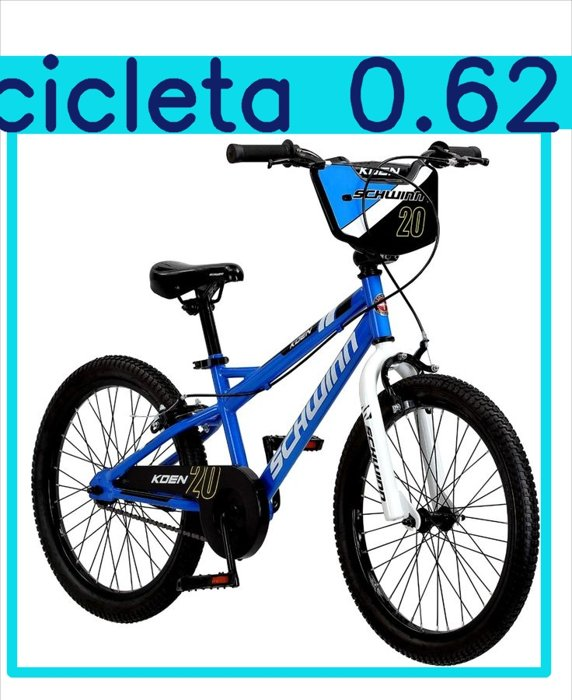

bicicleta_39.jpg


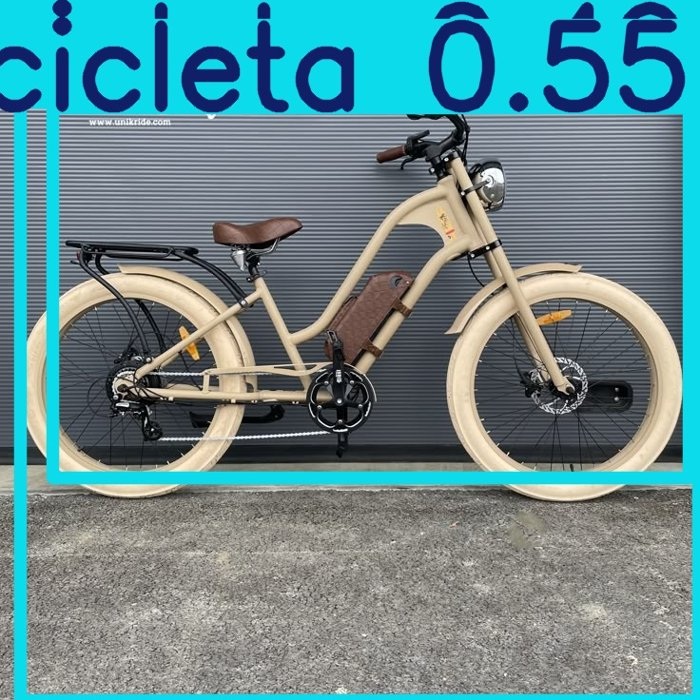

bicicleta_40.jpg


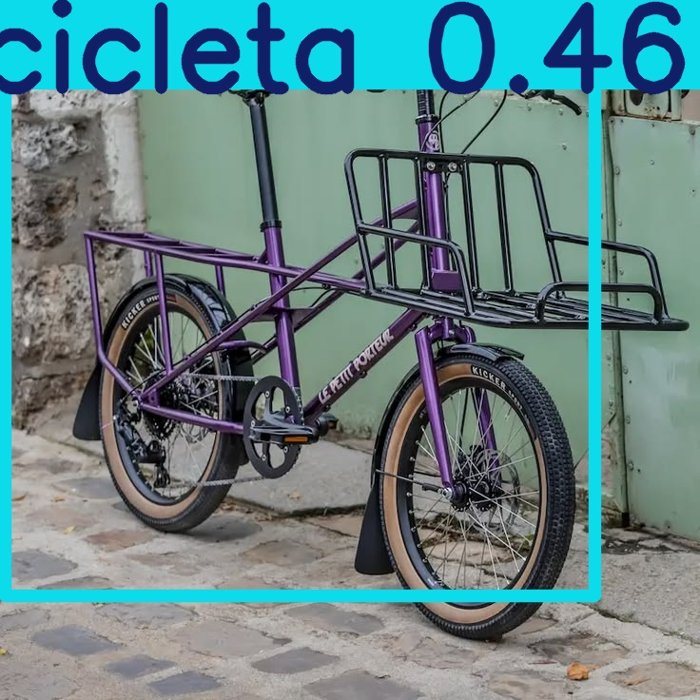

vaca_37.jpg


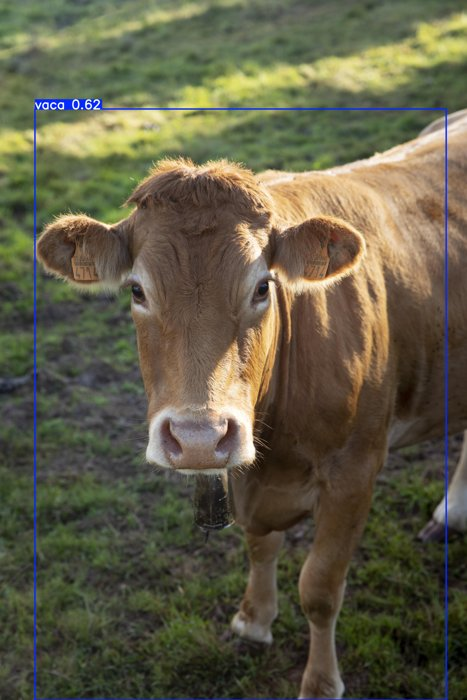

vaca_38.jpg


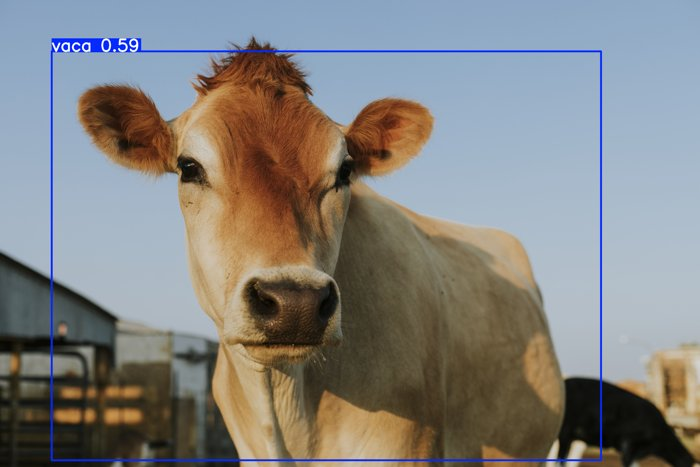

vaca_39.jpg


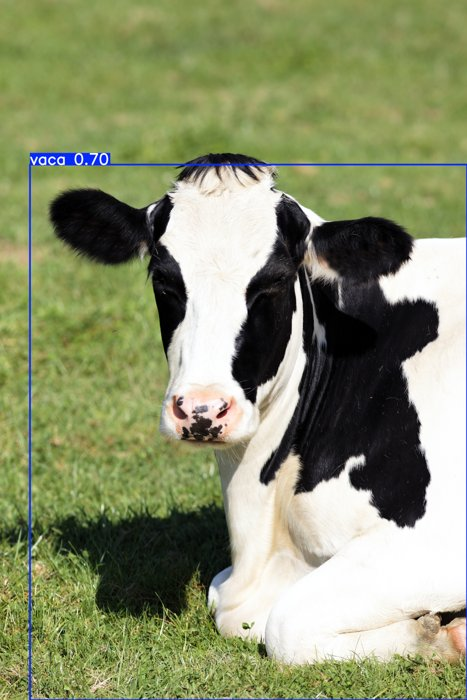

vaca_40.jpg


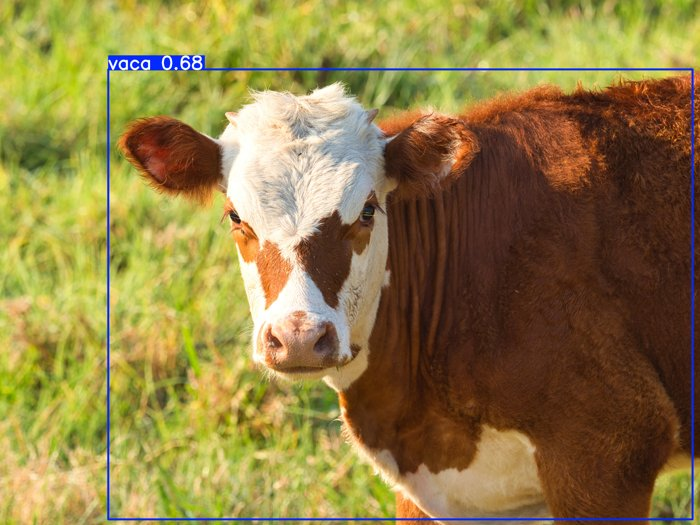

In [ ]:
# Mostra as detecções do modelo de 60 épocas nas imagens de teste
mostrar_resultados('/content/drive/MyDrive/FarmTech_Fase6/runs/detect/detect_60ep')

In [ ]:
# Mostra, para cada imagem, a classe, a posição da caixa e a confiança (última coluna) do modelo de 30 épocas
!tail -n +1 /content/drive/MyDrive/FarmTech_Fase6/runs/detect/detect_30ep/labels/*.txt

==> /content/drive/MyDrive/FarmTech_Fase6/runs/detect/detect_30ep/labels/bicicleta_38.txt <==
1 0.486413 0.552222 0.972826 0.895556 0.428037
1 0.486413 0.552222 0.972826 0.895556 0.428037

==> /content/drive/MyDrive/FarmTech_Fase6/runs/detect/detect_30ep/labels/bicicleta_39.txt <==
1 0.487772 0.411685 0.975543 0.720109 0.528276
1 0.487772 0.411685 0.975543 0.720109 0.528276

==> /content/drive/MyDrive/FarmTech_Fase6/runs/detect/detect_30ep/labels/bicicleta_40.txt <==
1 0.484375 0.417799 0.862772 0.835598 0.29412
1 0.484375 0.417799 0.862772 0.835598 0.29412

==> /content/drive/MyDrive/FarmTech_Fase6/runs/detect/detect_30ep/labels/vaca_37.txt <==
0 0.528013 0.624256 0.943973 0.751488 0.631584
0 0.528013 0.624256 0.943973 0.751488 0.631584

==> /content/drive/MyDrive/FarmTech_Fase6/runs/detect/detect_30ep/labels/vaca_38.txt <==
0 0.50496 0.5 0.990079 1 0.608992
0 0.50496 0.5 0.990079 1 0.608992

==> /content/drive/MyDrive/FarmTech_Fase6/runs/detect/detect_30ep/labels/vaca_39.txt <==
0 0.

In [ ]:
# Mostra, para cada imagem, a classe, a posição da caixa e a confiança (última coluna) do modelo de 60 épocas
!tail -n +1 /content/drive/MyDrive/FarmTech_Fase6/runs/detect/detect_60ep/labels/*.txt

==> /content/drive/MyDrive/FarmTech_Fase6/runs/detect/detect_60ep/labels/bicicleta_37.txt <==
1 0.534647 0.565897 0.900815 0.705163 0.325844
1 0.534647 0.565897 0.900815 0.705163 0.325844

==> /content/drive/MyDrive/FarmTech_Fase6/runs/detect/detect_60ep/labels/bicicleta_38.txt <==
1 0.487092 0.571667 0.933424 0.776667 0.621215
1 0.487092 0.571667 0.933424 0.776667 0.621215

==> /content/drive/MyDrive/FarmTech_Fase6/runs/detect/detect_60ep/labels/bicicleta_39.txt <==
1 0.512908 0.5 0.96875 1 0.485819
1 0.529212 0.417799 0.908967 0.528533 0.548066
1 0.512908 0.5 0.96875 1 0.485819
1 0.529212 0.417799 0.908967 0.528533 0.548066

==> /content/drive/MyDrive/FarmTech_Fase6/runs/detect/detect_60ep/labels/bicicleta_40.txt <==
1 0.427989 0.425272 0.842391 0.850543 0.464178
1 0.427989 0.425272 0.842391 0.850543 0.464178

==> /content/drive/MyDrive/FarmTech_Fase6/runs/detect/detect_60ep/labels/vaca_37.txt <==
0 0.515067 0.577827 0.88058 0.844345 0.623342
0 0.515067 0.577827 0.88058 0.844345 0.62

### 5.2 Teste (8 imagens nunca vistas)

| Métrica | 30 épocas | 60 épocas |
|---|---|---|
| Precisão | 0,842 | 0,899 |
| Recall | 0,964 | 0,713 |
| mAP50 | 0,995 | 0,912 |
| mAP50-95 | 0,649 | 0,736 |

Detecções nas imagens (confiança mínima 0,25): o modelo de 30 épocas detectou 7 dos 8 objetos (não detectou a bicicleta_37). O de 60 épocas detectou os 8, mas gerou uma caixa duplicada na bicicleta_39. A confiança das detecções ficou entre 0,29 e 0,73, sendo menor nas bicicletas.

Observação: o recall menor do modelo de 60 épocas no `val.py` não significa objetos sem detecção. O `val.py` compara cada caixa com o rótulo real e usa outro limiar de confiança, enquanto o `detect.py` só mostra o que foi desenhado com confiança acima de 0,25 e não confere se a caixa está no lugar certo.

## 6. Conclusões

**Pontos fortes:** o transfer learning com o YOLOv5s aprendeu a distinguir vaca de bicicleta com apenas 64 imagens de treino, cerca de 11 e 21 minutos. Todas as vacas foram detectadas pelos dois modelos.

**Comparação 30 x 60 épocas:** não houve um vencedor claro. O modelo de 60 épocas teve caixas melhores nas vacas, mas custou o dobro do tempo de treino e gerou uma caixa duplicada. O de 30 épocas perdeu uma bicicleta com o limiar de confiança de 0,25. A velocidade de inferência foi equivalente (cerca de 28 ms por imagem).

**Limitações:**
- Dataset pequeno, conforme proposto no enunciado (40 imagens por classe, sendo 32 para treino, 4 para validação e 4 para teste). Com validação e teste de apenas 8 imagens cada, qualquer erro pesa muito nas métricas.
- A validação foi otimista, pois o melhor modelo foi escolhido com base nela. O conjunto de teste é a medida mais confiável.
- As fotos de teste são quase todas close-ups ou imagens de produto, sem vacas ao longe, rebanhos ou bicicletas parcialmente visíveis.
- A confiança das detecções é baixa (entre 0,29 e 0,73), e o resultado depende do limiar de confiança escolhido.

**Próximos passos:** a melhora mais direta seria ampliar o dataset com mais imagens e maior variedade de cenas (vacas ao longe, rebanhos, bicicletas parcialmente visíveis, diferentes iluminações e fundos). Também vale testar outros limiares de confiança e comparar com outras abordagens, como o YOLO padrão e uma CNN treinada do zero (Entrega 2).